In [26]:
from typing import Annotated

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage

from langgraph.graph import StateGraph, START, END  
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

from langgraph.types import interrupt, Command

from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage #base message is parent class for human message, ai messagen and system message

In [27]:
load_dotenv()

import os
key = os.getenv("GROQ_API_KEY")
model = ChatGroq(model="llama-3.3-70b-versatile", api_key=key)
model.invoke("hello how are you").content

"Hello. I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or topics you'd like to discuss. How about you? How's your day going so far?"

In [28]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]  # add message is a reducer function telling not to overwrite the existing list, insted use add_message to append new messages


- **What it does:** The interrupt() function literally suspends the execution of the graph right at this line.

- **The Magic:** The graph doesn't just block the main thread like a standard Python input(). Instead, LangGraph effectively "goes to sleep." It saves the exact state of your application to a database (a checkpointer).

- **The Payload:** The dictionary you pass inside interrupt(...) is handed over to the human reviewer (perhaps rendered on a frontend UI). It gives them the exact context they need: What is the user asking? What do I need to approve?




- **what to send inside interrupt**
Think of the interrupt() function as a messenger. When the graph pauses, it needs to hand a "sticky note" to the human outside the graph so the human knows why the graph paused.

LangGraph does not care what is written on that sticky note. You can pass any data into interrupt(), as long as it is standard, saveable data (like a string, a list, or a dictionary).

In [29]:
#simple chat node BUT with HITL

def chatnode(state:ChatState):

    decision = interrupt({
        "type":"approval",
        "reason":"model is about to answer the user question",
        "questions": state["messages"][-1].content,
        "instruction":"approve this question? yes/no"
    })

    if decision["approved"] == "no":
        return {"messages": [AIMessage(content="not approved...")]}
    
    else:
        response = model.invoke(state["messages"])
        return {"messages": [response]}

In [30]:
#making of the graph

graph = StateGraph(ChatState)

graph.add_node("chat", chatnode)

graph.add_edge(START, "chat")
graph.add_edge("chat", END)


#checkpointers are required for interupts
checkpointer = MemorySaver()

app = graph.compile(checkpointer=checkpointer) #compile the graph

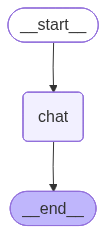

In [31]:
app

### Implementation

In [32]:
 #creating new thread id for this conversation
config = {"configurable": {"thread_id" : "1234"}}


#step -1 user ask the question
initial_state_input = {
    "messages": [
        ("user","what is the iran important country")
    ]
}


#invoke the graph for the first time
result = app.invoke(initial_state_input, config=config)

The awesome thing about LangChain and LangGraph is that they are smart enough to understand tuples as a shortcut.

Behind the scenes, LangGraph will automatically convert your tuple into:\n/n
**HumanMessage(content="what is the iran important country")**

In [33]:
result # we see user message and then flow reached chatnode, but it had the interupt() function and it has all the interrupt message

{'messages': [HumanMessage(content='what is the iran important country', additional_kwargs={}, response_metadata={}, id='01f88e64-3fec-43b5-b389-fe932e67cfa8')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'model is about to answer the user question', 'questions': 'what is the iran important country', 'instruction': 'approve this question? yes/no'}, id='eff7cee04b5a802386898502b47af765')]}

In [34]:
#extracting the interrupt message
message = result["__interrupt__"][0].value
message

{'type': 'approval',
 'reason': 'model is about to answer the user question',
 'questions': 'what is the iran important country',
 'instruction': 'approve this question? yes/no'}

In [35]:
# then we go at frontend show this message and ask if yes or no?
user_input = input(f"backend message: {message} \n approve this ques.? (yes/no)")

In [ ]:
# resume the graph with the approval decision
final_reault = app.invoke(
    Command(resume={"approved": user_input}), # by command we tell the langgraph not start from complete start, wake up the node that is currently sleeping and give this data
    config=config
)

In [37]:
print(final_reault)

{'messages': [HumanMessage(content='what is the iran important country', additional_kwargs={}, response_metadata={}, id='01f88e64-3fec-43b5-b389-fe932e67cfa8'), AIMessage(content="Iran is indeed a significant country in the world, and its importance can be understood from several perspectives. Here are some reasons why Iran is considered an important country:\n\n1. **Strategic Location**: Iran is situated in a crucial location, bordering the Middle East, Central Asia, and the South Caucasus. It shares borders with several important countries, including Iraq, Turkey, Afghanistan, and Pakistan, making it a vital player in regional politics and trade.\n2. **Energy Resources**: Iran is the world's fourth-largest oil producer and has the second-largest natural gas reserves. Its energy resources are a significant factor in the global energy market, and its position as a major oil exporter gives it considerable influence in the international energy sector.\n3. **Economic Importance**: Iran ha

### what happens after interrupt():
- pause the current execution
- save the state via checkpointers
- prepare a message from interrupt 
- send message to frontend


### at frontend:
- revice the interrupt message
- take the user input
- invoke BUT with command
- then langgrph continues from where we left but with additional data